In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
from matplotlib.lines import Line2D
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import  LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from matplotlib.colors import Normalize, ListedColormap
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [15]:
# Let's load our dataset
df = pd.read_csv('C:/Users/HP/OneDrive/7CS030/Assessment/nba_rookie_data.csv')

In [16]:
df.head()

,Name,Games Played,Minutes Played,Points Per Game,Field Goals Made,Field Goal Attempts,Field Goal Percent,3 Point Made,3 Point Attempt,3 Point Percent,...,Free Throw Attempts,Free Throw Percent,Offensive Rebounds,Defensive Rebounds,Rebounds,Assists,Steals,Blocks,Turnovers,TARGET_5Yrs
0,Brandon Ingram,36,27.4,7.4,2.6,7.6,34.7,0.5,2.1,25.0,...,2.3,69.9,0.7,3.4,4.1,1.9,0.4,0.4,1.3,0
1,Andrew Harrison,35,26.9,7.2,2.0,6.7,29.6,0.7,2.8,23.5,...,3.4,76.5,0.5,2.0,2.4,3.7,1.1,0.5,1.6,0
2,JaKarr Sampson,74,15.3,5.2,2.0,4.7,42.2,0.4,1.7,24.4,...,1.3,67.0,0.5,1.7,2.2,1.0,0.5,0.3,1.0,0
3,Malik Sealy,58,11.6,5.7,2.3,5.5,42.6,0.1,0.5,22.6,...,1.3,68.9,1.0,0.9,1.9,0.8,0.6,0.1,1.0,1
4,Matt Geiger,48,11.5,4.5,1.6,3.0,52.4,0.0,0.1,0.0,...,1.9,67.4,1.0,1.5,2.5,0.3,0.3,0.4,0.8,1


In [17]:
# Remove N/A values
df = df.dropna()

In [18]:
df.head

<bound method NDFrame.head of                  Name  Games Played  Minutes Played  Points Per Game  \
0      Brandon Ingram            36            27.4              7.4   
1     Andrew Harrison            35            26.9              7.2   
2      JaKarr Sampson            74            15.3              5.2   
3         Malik Sealy            58            11.6              5.7   
4         Matt Geiger            48            11.5              4.5   
...               ...           ...             ...              ...   
1335      Chris Smith            80            15.8              4.3   
1336      Brent Price            68            12.6              3.9   
1337     Marlon Maxey            43            12.1              5.4   
1338  Litterial Green            52            12.0              4.5   
1339        Jon Barry            47            11.7              4.4   

      Field Goals Made  Field Goal Attempts  Field Goal Percent  3 Point Made  \
0                  2.6  

In [19]:
df.shape

(1329, 21)

In [20]:
# Let's convert features to numerical values
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [21]:
target_column_index = 20
X = df.drop(df.columns[target_column_index], axis=1) 
y = df.iloc[:, target_column_index]

In [22]:
y.head

<bound method NDFrame.head of 0       0
1       0
2       0
3       1
4       1
       ..
1335    0
1336    1
1337    0
1338    1
1339    1
Name: TARGET_5Yrs, Length: 1329, dtype: int64>

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [24]:
# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [47]:
# Features using logistic and hiden layers
mlp = MLPClassifier(hidden_layer_sizes=(50,100,200), activation='logistic', max_iter=2000, random_state=42)
mlp.fit(X_train, y_train)

y_pred = mlp.predict(X_test)

In [48]:
# print the accuracy score & number of mislabeled points 
print('Accuracy is %.2f' %mlp.score(X_test,y_test))
print('Number of mislabeled points out of a total %d points: %d'
      % (X_test.shape[0], (y_test != mlp.predict(X_test)).sum()))

Accuracy is 0.70
Number of mislabeled points out of a total 266 points: 80


In [49]:
# Features using logistic without hiden layers
mlp = MLPClassifier(hidden_layer_sizes=(), activation='logistic', max_iter=2000, random_state=42)
mlp.fit(X_train, y_train)

y_pred = mlp.predict(X_test)

In [50]:
# print the accuracy score & number of mislabeled points
print('Accuracy is %.2f' %mlp.score(X_test,y_test))
print('Number of mislabeled points out of a total %d points: %d'
      % (X_test.shape[0], (y_test != mlp.predict(X_test)).sum()))

Accuracy is 0.71
Number of mislabeled points out of a total 266 points: 77


In [51]:
# Features using relu with hiden layers
mlp = MLPClassifier(hidden_layer_sizes=(50,100,200), activation='relu', max_iter=2000, random_state=42)
mlp.fit(X_train, y_train)

y_pred = mlp.predict(X_test)

In [52]:
# print the accuracy score & number of mislabeled points
print('Accuracy is %.2f' %mlp.score(X_test,y_test))
print('Number of mislabeled points out of a total %d points: %d'
      % (X_test.shape[0], (y_test != mlp.predict(X_test)).sum()))

Accuracy is 0.63
Number of mislabeled points out of a total 266 points: 98


In [53]:
# Features using Tanh with hiden layers
mlp = MLPClassifier(hidden_layer_sizes=(50,100,200), activation='tanh', max_iter=2000, random_state=42)
mlp.fit(X_train, y_train)

y_pred = mlp.predict(X_test)

In [54]:
# print the accuracy score & number of mislabeled points 
print('Accuracy is %.2f' %mlp.score(X_test,y_test))
print('Number of mislabeled points out of a total %d points: %d'
      % (X_test.shape[0], (y_test != mlp.predict(X_test)).sum()))

Accuracy is 0.64
Number of mislabeled points out of a total 266 points: 96


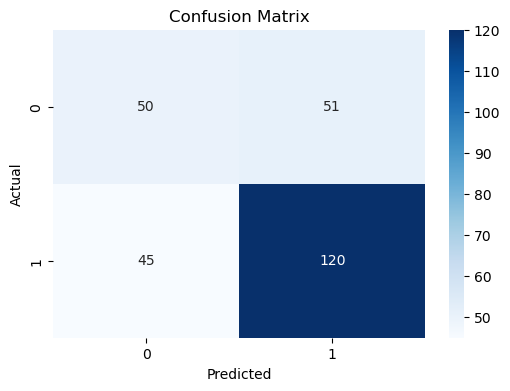

In [55]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("my_plot_Confusion.png") 
plt.show()

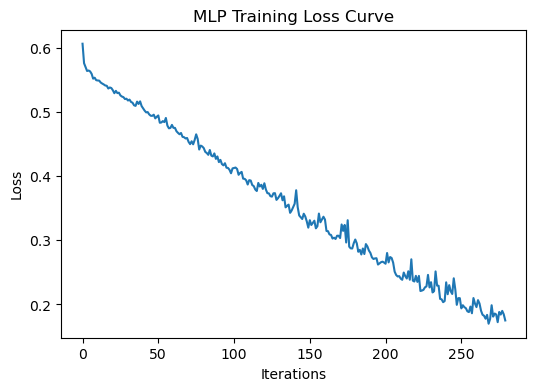

In [56]:
plt.figure(figsize=(6,4))
plt.plot(mlp.loss_curve_)
plt.title("MLP Training Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.savefig("my_plot.png") 
plt.show()

In [57]:
X1 = X.iloc[:, [1,2,3,4]].values
y = df.iloc[:, target_column_index]

In [58]:
X1_train, X1_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [64]:
# 4 features using Logistic function with hidden layers
mlp = MLPClassifier(hidden_layer_sizes=(50, 30, 20), activation='logistic', max_iter=2000, random_state=42)
mlp.fit(X1_train, y_train)

MLPClassifier(activation='logistic', hidden_layer_sizes=(50, 30, 20),
              max_iter=2000, random_state=42)

In [65]:
# print the accuracy score & number of mislabeled points 
print('Accuracy is %.2f' %mlp.score(X1_test,y_test))
print('Number of mislabeled points out of a total %d points: %d'
      % (X1_test.shape[0], (y_test != mlp.predict(X1_test)).sum()))

Accuracy is 0.70
Number of mislabeled points out of a total 266 points: 81


In [66]:
# 4 features using Logistic function without hidden layers
mlp = MLPClassifier(hidden_layer_sizes=(), activation='logistic', max_iter=2000, random_state=42)
mlp.fit(X1_train, y_train)

MLPClassifier(activation='logistic', hidden_layer_sizes=(), max_iter=2000,
              random_state=42)

In [67]:
# print the accuracy score & number of mislabeled points 
print('Accuracy is %.2f' %mlp.score(X1_test,y_test))
print('Number of mislabeled points out of a total %d points: %d'
      % (X1_test.shape[0], (y_test != mlp.predict(X1_test)).sum()))

Accuracy is 0.69
Number of mislabeled points out of a total 266 points: 83


In [68]:
# 4 features using relu function with hidden layers
mlp = MLPClassifier(hidden_layer_sizes=(50, 30, 20), activation='relu', max_iter=2000, random_state=42)
mlp.fit(X1_train, y_train)

MLPClassifier(hidden_layer_sizes=(50, 30, 20), max_iter=2000, random_state=42)

In [69]:
# print the accuracy score & number of mislabeled points 
print('Accuracy is %.2f' %mlp.score(X1_test,y_test))
print('Number of mislabeled points out of a total %d points: %d'
      % (X1_test.shape[0], (y_test != mlp.predict(X1_test)).sum()))

Accuracy is 0.66
Number of mislabeled points out of a total 266 points: 90


In [70]:
# 4 features using tanh function with hidden layers
mlp = MLPClassifier(hidden_layer_sizes=(50, 30, 20), activation='tanh', max_iter=2000, random_state=42)
mlp.fit(X1_train, y_train)

MLPClassifier(activation='tanh', hidden_layer_sizes=(50, 30, 20), max_iter=2000,
              random_state=42)

In [71]:
# print the accuracy score & number of mislabeled points 
print('Accuracy is %.2f' %mlp.score(X1_test,y_test))
print('Number of mislabeled points out of a total %d points: %d'
      % (X1_test.shape[0], (y_test != mlp.predict(X1_test)).sum()))

Accuracy is 0.67
Number of mislabeled points out of a total 266 points: 88


In [73]:
# For 2 Features
X2 = X.iloc[:, [1,2]].values

In [74]:
X2_train, X2_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [75]:
# 2 features using Logistic function with hidden layers
mlp = MLPClassifier(hidden_layer_sizes=(50, 30, 20), activation='logistic', max_iter=2000, random_state=42)
mlp.fit(X2_train, y_train)

MLPClassifier(activation='logistic', hidden_layer_sizes=(50, 30, 20),
              max_iter=2000, random_state=42)

In [76]:
# print the accuracy score & number of mislabeled points
print('Accuracy is %.2f' %mlp.score(X2_test,y_test))
print('Number of mislabeled points out of a total %d points: %d'
      % (X2_test.shape[0], (y_test != mlp.predict(X2_test)).sum()))

Accuracy is 0.70
Number of mislabeled points out of a total 266 points: 81


In [77]:
# 2 features using Logistic function witout hidden layers
mlp = MLPClassifier(hidden_layer_sizes=(), activation='logistic', max_iter=2000, random_state=42)
mlp.fit(X2_train, y_train)

MLPClassifier(activation='logistic', hidden_layer_sizes=(), max_iter=2000,
              random_state=42)

In [78]:
# print the accuracy score & number of mislabeled points
print('Accuracy is %.2f' %mlp.score(X2_test,y_test))
print('Number of mislabeled points out of a total %d points: %d'
      % (X2_test.shape[0], (y_test != mlp.predict(X2_test)).sum()))

Accuracy is 0.69
Number of mislabeled points out of a total 266 points: 83


In [79]:
# 2 features using relu function with hidden layers
mlp = MLPClassifier(hidden_layer_sizes=(50, 30, 20), activation='relu', max_iter=2000, random_state=42)
mlp.fit(X2_train, y_train)

MLPClassifier(hidden_layer_sizes=(50, 30, 20), max_iter=2000, random_state=42)

In [80]:
# print the accuracy score & number of mislabeled points
print('Accuracy is %.2f' %mlp.score(X2_test,y_test))
print('Number of mislabeled points out of a total %d points: %d'
      % (X2_test.shape[0], (y_test != mlp.predict(X2_test)).sum()))

Accuracy is 0.66
Number of mislabeled points out of a total 266 points: 90


In [81]:
# 2 features using tanh function with hidden layers
mlp = MLPClassifier(hidden_layer_sizes=(50, 30, 20), activation='tanh', max_iter=2000, random_state=42)
mlp.fit(X2_train, y_train)

MLPClassifier(activation='tanh', hidden_layer_sizes=(50, 30, 20), max_iter=2000,
              random_state=42)

In [82]:
# print the accuracy score & number of mislabeled points
print('Accuracy is %.2f' %mlp.score(X2_test,y_test))
print('Number of mislabeled points out of a total %d points: %d'
      % (X2_test.shape[0], (y_test != mlp.predict(X2_test)).sum()))

Accuracy is 0.67
Number of mislabeled points out of a total 266 points: 88


In [83]:
scaler = StandardScaler()
X2_scaled = scaler.fit_transform(X)

# Train the MLP model
mlp = MLPClassifier(hidden_layer_sizes=(10,), max_iter=1000)
mlp.fit(X2_scaled, y)

MLPClassifier(hidden_layer_sizes=(10,), max_iter=1000)

In [84]:
# Select only the two columns *before* the train/test split
features = ['Games Played', 'Minutes Played']
X2 = df[features]
y = df['TARGET_5Yrs']

from sklearn.model_selection import train_test_split
X2_train, X2_test, y_train, y_test = train_test_split(X2, y, test_size=0.2, random_state=42)

mlp.fit(X2_train, y_train)

MLPClassifier(hidden_layer_sizes=(10,), max_iter=1000)

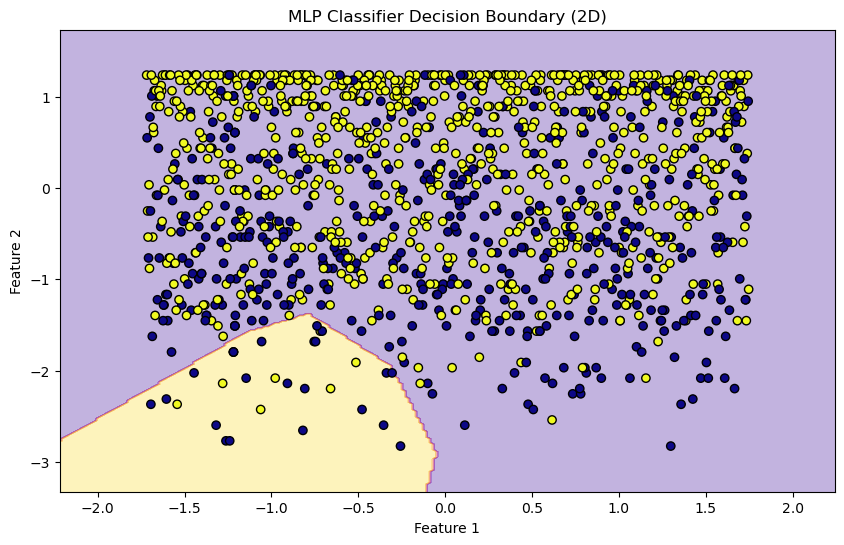

In [89]:
x_min, x_max = X2_scaled[:, 0].min() - 0.5, X2_scaled[:, 0].max() + 0.5  # Changed X_scaled to X2_scaled
y_min, y_max = X2_scaled[:, 1].min() - 0.5, X2_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# --- Predict across the grid ---
# Create a DataFrame with the same feature names as the training data
mesh_data = pd.DataFrame(
    np.c_[xx.ravel(), yy.ravel()], 
    columns=mlp.feature_names_in_ ) # Use the feature names from the trained model

Z = mlp.predict(mesh_data)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='plasma')
plt.scatter(X2_scaled[:, 0], X2_scaled[:, 1], c=y, edgecolor='k', cmap='plasma')
plt.title('MLP Classifier Decision Boundary (2D)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.savefig('MLP.PNG')
plt.show()